<a href="https://colab.research.google.com/github/SahilRaut80/Assignments/blob/main/SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [108]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [109]:
df = pd.read_csv('/content/Pharma_Industry.csv')

In [110]:
df.shape

(500, 6)

In [111]:
df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


In [112]:
df.isnull().sum()

,0
Drug Dosage (mg),0
Systolic Blood Pressure (mmHg),0
Heart Rate (BPM),0
Liver Toxicity Index (U/L),0
Blood Glucose Level (mg/dL),0
Drug Response,0


In [113]:
df.duplicated().sum()

np.int64(0)

In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [115]:
df.describe()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,-0.037761,0.214957,0.062871,0.054398,-0.171863,0.5200
std,0.979891,1.247567,0.971978,0.986001,0.983765,0.5001
min,-3.019512,-3.773897,-2.940389,-3.401277,-3.110431,0.0000
25%,-0.642003,-0.565168,-0.648157,-0.586085,-0.797715,0.0000
50%,-0.019340,0.201532,0.027732,-0.065661,-0.108106,1.0000
75%,0.641151,0.951375,0.710774,0.633914,0.513555,1.0000
max,2.949094,4.111751,3.193108,3.373269,2.518023,1.0000


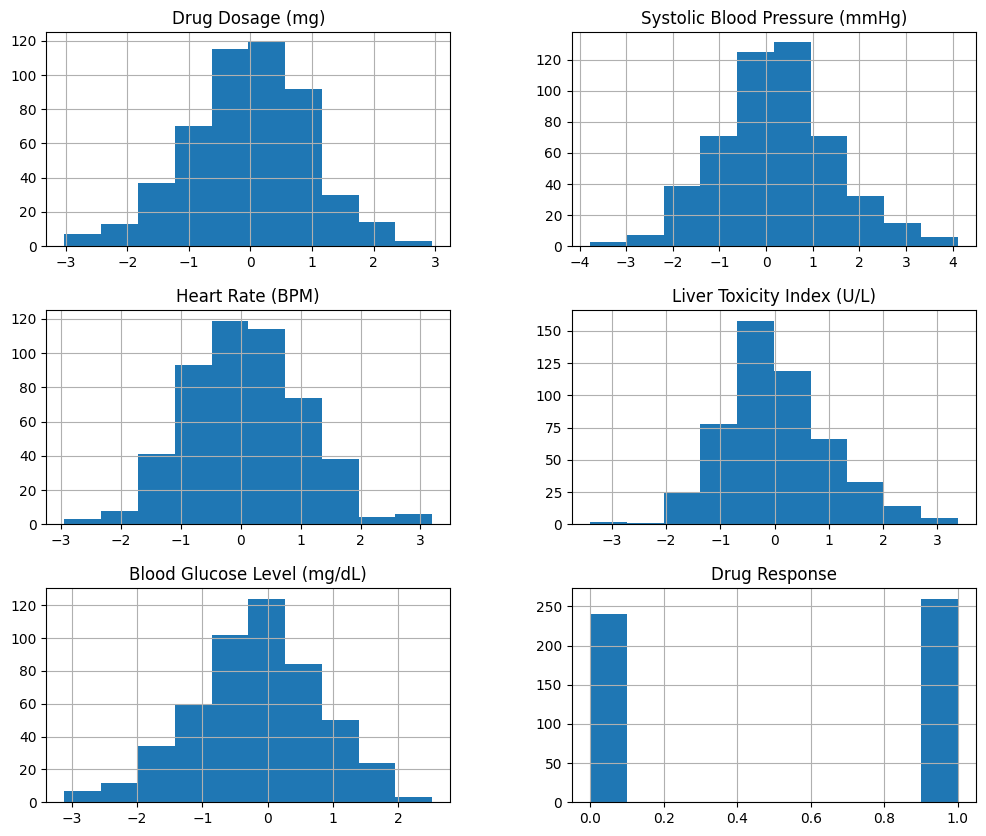

In [116]:
df.hist(figsize=(12,10))
plt.show()

<Axes: >

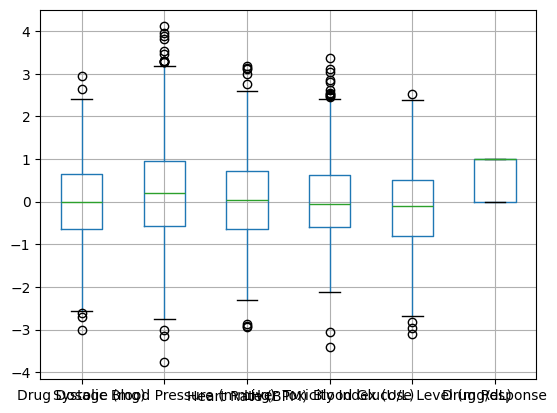

In [117]:
df.boxplot()

In [118]:
for i in df.select_dtypes(include= ['int','float']).columns:

  q1 = df[i].quantile(0.25)
  q3 = df[i].quantile(0.75)
  IQR = q3 - q1
  lower_bound = q1-1.5*IQR
  uppere_bound = q3+1.5*IQR

  df[i] = df[i].clip(lower_bound,uppere_bound)

<Axes: >

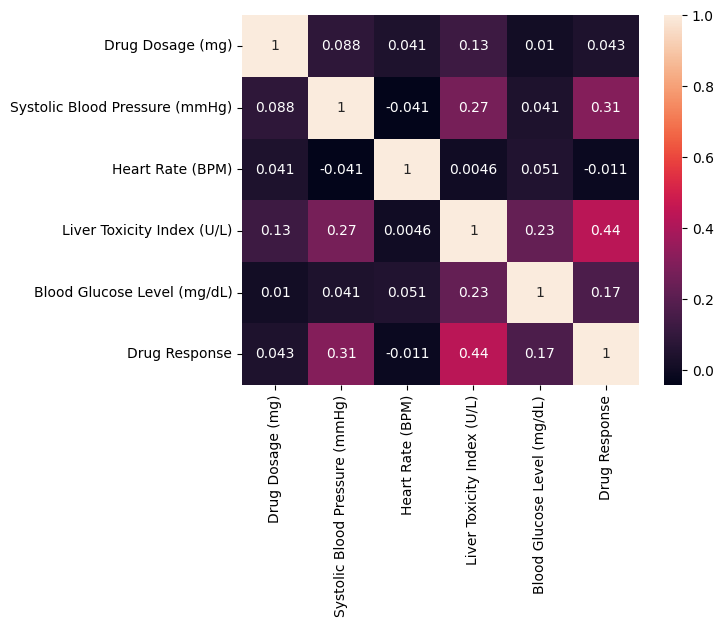

In [119]:

sns.heatmap(df.corr(),annot = True)

In [120]:
x = df.drop(columns=['Drug Response'])
y = df['Drug Response']

In [121]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2, random_state=55)

In [122]:
from sklearn.svm import SVC
sv = SVC()
sv.fit(x_train,y_train)
pred_train = sv.predict(x_train)
pred = sv.predict(x_test)

In [123]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(accuracy_score(y_train,pred_train))
print(accuracy_score(y_test,pred))
print(confusion_matrix(y_test,pred))
print(classification_report(y_test,pred))

0.8075
0.78
[[37  7]
 [15 41]]
              precision    recall  f1-score   support

           0       0.71      0.84      0.77        44
           1       0.85      0.73      0.79        56

    accuracy                           0.78       100
   macro avg       0.78      0.79      0.78       100
weighted avg       0.79      0.78      0.78       100



In [124]:
from sklearn.svm import SVC
sv = SVC(kernel='poly')
sv.fit(x_train,y_train)
pred_train = sv.predict(x_train)
pred = sv.predict(x_test)
print(accuracy_score(y_train,pred_train))
print(accuracy_score(y_test,pred))

0.755
0.72


In [125]:
from sklearn.svm import SVC
sv = SVC(kernel='linear')
sv.fit(x_train,y_train)
pred_train = sv.predict(x_train)
pred = sv.predict(x_test)
print(accuracy_score(y_train,pred_train))
print(accuracy_score(y_test,pred))

0.71
0.76


In [126]:
from sklearn.svm import SVC
sv = SVC(kernel='sigmoid')
sv.fit(x_train,y_train)
pred_train = sv.predict(x_train)
pred = sv.predict(x_test)
print(accuracy_score(y_train,pred_train))
print(accuracy_score(y_test,pred))

0.625
0.65


In [127]:
x_test = x_test.to_numpy()
y_test = y_test.to_numpy()


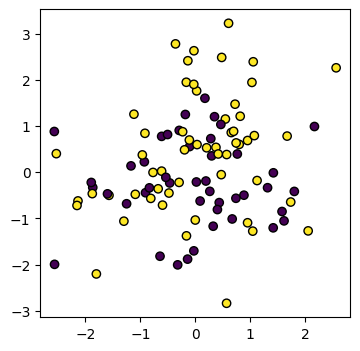

In [128]:
plt.figure(figsize=(4,4))
plt.scatter(x_test[:, 0], x_test[:, 1], c=y_test, edgecolors='black')
plt.show()

In [133]:
config = [
    {'kernel': 'linear','C':0.1},
    {'kernel': 'linear','C':1},
    {'kernel': 'rbf', 'C':0.1},
    {'kernel': 'rbf', 'C':1,'gamma': 1} ]


for params in config:
    sv  = SVC(**params)
    sv.fit(x_train,y_train)
    pred = sv.predict(x_test)

    print(params,accuracy_score(y_test,pred))




{'kernel': 'linear', 'C': 0.1} 0.75
{'kernel': 'linear', 'C': 1} 0.76
{'kernel': 'rbf', 'C': 0.1} 0.77
{'kernel': 'rbf', 'C': 1, 'gamma': 1} 0.79


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


1.	Compare SVM performance with various kernels (e.g., linear, polynomial, radial basis function).

The performance of SVM was evaluated using different kernel functions such as linear, polynomial, and radial basis function (RBF). The linear kernel produced moderate performance as it assumes a linear decision boundary. The polynomial kernel captured more complex relationships but required careful tuning. The RBF kernel performed the best as it effectively handled non-linear patterns in the dataset

2.	Analyze SVM strengths and weaknesses for the dataset based on EDA and visualization results.

--> strengths:
SVM performed well on the dataset due to its ability to handle non-linear relationships between features. The model was effective even though the correlation between variables was moderate.

--> weakness:
SVM is sensitive to hyperparameters such as C and gamma. Improper tuning (e.g., very high gamma) led to overfitting, resulting in perfect accuracy that may not generalize well. Additionally, SVM requires feature scaling and is less interpretable compared to simpler models.

3.	Discuss practical implications of SVM in real-world classification tasks.

SVM is widely used in real-world classification tasks such as medical diagnosis, drug response prediction, image classification, and text classification. Its ability to handle high-dimensional data and non-linear relationships makes it suitable for complex datasets